# Agentic RAG From Scratch: Building with LangGraph and Open-Source Models

In this notebook, we'll look under the hood of `create_agent` and build an agentic RAG application **from scratch** using LangGraph's low-level primitives and locally-hosted open-source models.

**Learning Objectives:**
- Understand LangGraph's core constructs: StateGraph, nodes, edges, and conditional routing
- Build a ReAct agent from scratch without high-level abstractions
- Use Ollama to run open-source models locally (gpt-oss:20b + embeddinggemma)
- Transition from `aimakerspace` utilities to the LangChain ecosystem

## Table of Contents:

- **Breakout Room #1:** LangGraph Fundamentals & Building Agents from Scratch
  - Task 1: Dependencies & Ollama Setup
  - Task 2: LangGraph Core Concepts (StateGraph, Nodes, Edges)
  - Task 3: Building a ReAct Agent from Scratch
  - Task 4: Adding Tools to Your Agent
  - Question #1 & Question #2
  - Activity #1: Implement a Custom Routing Function

- **Breakout Room #2:** Agentic RAG with Local Models
  - Task 5: Loading & Chunking with LangChain
  - Task 6: Setting up Qdrant with Local Embeddings
  - Task 7: Creating a RAG Tool
  - Task 8: Building Agentic RAG from Scratch
  - Question #3 & Question #4
  - Activity #2: Extend the Agent with Memory

---
# Breakout Room #1
## LangGraph Fundamentals & Building Agents from Scratch

## Task 1: Dependencies & Ollama Setup

Before we begin, make sure you have:

1. **Ollama installed** - Download from [ollama.com](https://ollama.com/)
2. **Ollama running** - Start with `ollama serve` in a terminal
3. **Models pulled** - Run these commands:

```bash
# Chat model for reasoning and generation (~12GB)
ollama pull gpt-oss:20b

# Embedding model for RAG (~622MB)
ollama pull embeddinggemma
```

> **Note**: If you don't have enough RAM/VRAM for `gpt-oss:20b` (requires 16GB+ VRAM or 24GB+ RAM), you can substitute with `llama3.2:3b` or another smaller model.

**📚 Documentation:**
- [Ollama Installation Guide](https://ollama.com/download)
- [gpt-oss Model Card](https://ollama.com/library/gpt-oss)
- [EmbeddingGemma Model Card](https://ollama.com/library/embeddinggemma)
- [langchain-ollama Integration](https://python.langchain.com/docs/integrations/providers/ollama/)

In [1]:
# Core imports we'll use throughout the notebook
import os
import getpass
import json
from uuid import uuid4
from typing import Annotated, TypedDict, Literal

import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

In [2]:
# Verify Ollama is running and models are available
from langchain_ollama import ChatOllama, OllamaEmbeddings

# Test connection to Ollama
try:
    test_llm = ChatOllama(model="gpt-oss:20b", temperature=0)
    test_response = test_llm.invoke("Say 'Ollama is working!' in exactly 3 words.")
    print(f"Chat Model Test: {test_response.content}")
    
    test_embeddings = OllamaEmbeddings(model="embeddinggemma")
    test_vector = test_embeddings.embed_query("test")
    print(f"Embedding Model Test: Vector dimension = {len(test_vector)}")
    print("\nOllama is ready!")
except Exception as e:
    print(f"Error connecting to Ollama: {e}")
    print("\nMake sure:")
    print("1. Ollama is installed: https://ollama.com/")
    print("2. Ollama is running: 'ollama serve'")
    print("3. Models are pulled: 'ollama pull gpt-oss:20b' and 'ollama pull embeddinggemma'")

Chat Model Test: Ollama is working!
Embedding Model Test: Vector dimension = 768

Ollama is ready!


## Task 2: LangGraph Core Concepts

In Session 3, we used `create_agent` which abstracts away the complexity. Now let's understand what's happening under the hood!

### LangGraph models workflows as **graphs** with three key components:

### 1. State
A shared data structure that represents the current snapshot of your application:

```python
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]  # Conversation history
```

The `add_messages` **reducer** ensures new messages are appended (not replaced) when the state updates.

### 2. Nodes
Python functions that encode the logic of your agent:
- Receive the current state
- Perform computation or side-effects
- Return an updated state

### 3. Edges
Functions that determine which node to execute next:
- **Normal edges**: Always go to a specific node
- **Conditional edges**: Choose the next node based on state

**📚 Documentation:**
- [LangGraph Low-Level Concepts](https://langchain-ai.github.io/langgraph/concepts/low_level/)
- [LangGraph Quickstart](https://langchain-ai.github.io/langgraph/tutorials/introduction/)
- [StateGraph API Reference](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph)

In [3]:
# Let's build our first LangGraph workflow - a simple echo graph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# Step 1: Define the State
class SimpleState(TypedDict):
    messages: Annotated[list, add_messages]

# Step 2: Define Nodes (functions that process state)
def echo_node(state: SimpleState):
    """A simple node that echoes the last message."""
    last_message = state["messages"][-1]
    echo_response = AIMessage(content=f"You said: {last_message.content}")
    return {"messages": [echo_response]}

# Step 3: Build the Graph
echo_graph = StateGraph(SimpleState)

# Add nodes
echo_graph.add_node("echo", echo_node)

# Add edges (START -> echo -> END)
echo_graph.add_edge(START, "echo")
echo_graph.add_edge("echo", END)

# Compile the graph
echo_app = echo_graph.compile()

print("Simple echo graph created!")

Simple echo graph created!


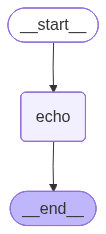

In [4]:
# Visualize the graph structure
try:
    from IPython.display import display, Image
    display(Image(echo_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph image: {e}")
    print("\nGraph structure (ASCII):")
    print(echo_app.get_graph().draw_ascii())

In [5]:
# Test the echo graph
result = echo_app.invoke({"messages": [HumanMessage(content="Greetings LangGraph!")]})

print("Conversation:")
for msg in result["messages"]:
    role = "Human" if isinstance(msg, HumanMessage) else "AI"
    print(f"  [{role}]: {msg.content}")

Conversation:
  [Human]: Greetings LangGraph!
  [AI]: You said: Greetings LangGraph!


## Task 3: Building a ReAct Agent from Scratch

Now let's build something more sophisticated: a **ReAct agent** that can:
1. **Reason** about what to do
2. **Act** by calling tools
3. **Observe** results
4. **Repeat** until done

This is exactly what `create_agent` does under the hood. Let's build it ourselves!

### The Agent Loop Architecture

```
                    ┌──────────────┐
                    │    START     │
                    └──────┬───────┘
                           │
                           ▼
                    ┌──────────────┐
             ┌─────►│    agent     │◄────────┐
             │      │  (call LLM)  │         │
             │      └──────┬───────┘         │
             │             │                 │
             │             ▼                 │
             │      ┌──────────────┐         │
             │      │ should_      │         │
             │      │ continue?    │         │
             │      └──────┬───────┘         │
             │             │                 │
             │    tool_calls?                │
             │     │           │             │
             │    YES         NO             │
             │     │           │             │
             │     ▼           ▼             │
             │ ┌────────┐  ┌───────┐         │
             │ │ tools  │  │  END  │         │
             └─┤(execute│  └───────┘         │
               │ tools) ├────────────────────┘
               └────────┘
```

**📚 Documentation:**
- [How to create a ReAct agent from scratch](https://langchain-ai.github.io/langgraph/how-tos/react-agent-from-scratch/)
- [ReAct Agent Conceptual Guide](https://langchain-ai.github.io/langgraph/concepts/agentic_concepts/#react-agent)

In [6]:
from langchain_core.messages import BaseMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt

# Step 1: Define the Agent State
class AgentState(TypedDict):
    """The state of our agent - just a list of messages."""
    messages: Annotated[list[BaseMessage], add_messages]

print("AgentState defined with messages field")

AgentState defined with messages field


In [7]:
# Step 2: Initialize our local LLM with Ollama
llm = ChatOllama(
    model="gpt-oss:20b",
    temperature=0,  # Deterministic for reproducibility
)

print(f"LLM initialized: {llm.model}")

LLM initialized: gpt-oss:20b


## Task 4: Adding Tools to Your Agent

Tools are functions that the agent can call. We use the `@tool` decorator and **bind** them to the LLM.

**📚 Documentation:**
- [LangChain Tools Conceptual Guide](https://python.langchain.com/docs/concepts/tools/)
- [@tool Decorator Reference](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.convert.tool.html)
- [ToolNode Prebuilt](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode)

In [8]:
# Step 3: Define Tools
@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression. Use this for any math calculations.
    
    Args:
        expression: A mathematical expression to evaluate (e.g., '2 + 2', '10 * 5')
    """
    try:
        # Using eval with restricted globals for safety
        result = eval(expression, {"__builtins__": {}}, {})
        return f"The result of {expression} is {result}"
    except Exception as e:
        return f"Error evaluating expression: {e}"

@tool
def get_current_time() -> str:
    """Get the current date and time. Use this when the user asks about the current time or date."""
    from datetime import datetime
    return f"The current date and time is: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"

# Create our tool list
tools = [calculate, get_current_time]

# Bind tools to the LLM - this tells the LLM about available tools
llm_with_tools = llm.bind_tools(tools)

print("Tools defined and bound to LLM:")
for t in tools:
    print(f"  - {t.name}: {t.description[:50]}...")

Tools defined and bound to LLM:
  - calculate: Evaluate a mathematical expression. Use this for a...
  - get_current_time: Get the current date and time. Use this when the u...


In [9]:
# Step 4: Define the Agent Node (calls the LLM)
SYSTEM_PROMPT = """You are a helpful assistant that can perform calculations and tell the time.
Always use the available tools when appropriate.
Be concise in your responses, but always respond as if you are a pirate."""

def agent_node(state: AgentState):
    """The agent node - calls the LLM with the current conversation."""
    # Prepare messages with system prompt
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    
    # Call the LLM
    response = llm_with_tools.invoke(messages)
    
    # Return the response to be added to state
    return {"messages": [response]}

print("Agent node defined")

Agent node defined


In [10]:
# Step 5: Define the Tool Node (executes tools)
# We can use LangGraph's prebuilt ToolNode for convenience
tool_node = ToolNode(tools)

print("Tool node created using ToolNode prebuilt")

Tool node created using ToolNode prebuilt


In [26]:
# Step 6: Define the Conditional Edge (routing logic)

def should_continue(state: AgentState) -> Literal["thinking", "end"]:
    """Route to thinking before tools"""
    last_message = state["messages"][-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "thinking"  # Always think before acting! 
    
    return "end"

print("Conditional routing function defined")

Conditional routing function defined


In [27]:
# Step 7: Build the Graph!
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_node("thinking", thinking_node)  # thinking node added

# Set the entry point
workflow.add_edge(START, "agent")

# Modified conditonal edge from agent to thinking
workflow.add_conditional_edges(
    "agent", 
    should_continue, 
    {
        "thinking": "thinking",  # if there are tool calls, go to thinking first
         "end": END # if there are no tool calls, go to end
    }
)

workflow.add_edge("thinking", "tools") # Now thinking to tools
workflow.add_edge("tools", "agent") # Now tools to agent - the loop!

# Compile the graph
agent = workflow.compile()

print("ReAct agent with thinking step built from scratch!")

ReAct agent with thinking step built from scratch!


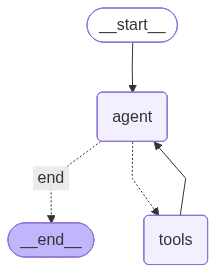

In [ ]:
# Visualize our agent
try:
    from IPython.display import display, Image
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph image: {e}")
    print("\nGraph structure (ASCII):")
    print(agent.get_graph().draw_ascii())

In [ ]:
# Test our agent!
print("Testing our from-scratch agent:")
print("=" * 50)

response = agent.invoke({"messages": [HumanMessage(content="What is 25 * 48?")]})

print("\nConversation:")
for msg in response["messages"]:
    msg_type = type(msg).__name__
    content = msg.content if msg.content else f"[Tool calls: {msg.tool_calls}]" if hasattr(msg, 'tool_calls') and msg.tool_calls else "[No content]"
    print(f"  [{msg_type}]: {content[:200]}")

Testing our from-scratch agent:

Conversation:
  [HumanMessage]: What is 25 * 48?
  [AIMessage]: [Tool calls: [{'name': 'calculate', 'args': {'expression': '25 * 48'}, 'id': '74a25ad1-1b47-4cfe-89eb-bda75b5be8f5', 'type': 'tool_call'}]]
  [ToolMessage]: The result of 25 * 48 is 1200
  [AIMessage]: Arrr, the booty be 1,200, matey!


In [ ]:
# Test with multiple tools
print("Testing with multiple tool calls:")
print("=" * 50)

response = agent.invoke({
    "messages": [HumanMessage(content="What time is it, and what is 100 divided by the current hour?")]
})

print("\nFinal response:")
print(response["messages"][-1].content)

Testing with multiple tool calls:

Final response:
Arrr, the clock reads 10:38:01, matey! And 100 divided by the current hour (10) be 10. Shiver me timbers!


In [ ]:
# Stream the agent's execution to see it step by step
print("Streaming agent execution:")
print("=" * 50)

for chunk in agent.stream(
    {"messages": [HumanMessage(content="Calculate 15% of 200")]},
    stream_mode="updates"
):
    for node_name, values in chunk.items():
        print(f"\n[Node: {node_name}]")
        if "messages" in values:
            for msg in values["messages"]:
                if hasattr(msg, 'content') and msg.content:
                    print(f"  Content: {msg.content[:200]}")
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    print(f"  Tool calls: {[tc['name'] for tc in msg.tool_calls]}")

Streaming agent execution:

[Node: agent]
  Tool calls: ['calculate']

[Node: tools]
  Content: The result of 0.15*200 is 30.0

[Node: agent]
  Content: Arrr, the booty be 30!


---
## ❓ Question #1:

In our from-scratch agent, we defined a `should_continue` function that returns either `"tools"` or `"end"`. How does this compare to how `create_agent` handles the same decision? What additional logic might `create_agent` include that we didn't implement?

The decision to call a tool or end the loop is handled the same way regardless of whether it involves create_agent or should_continue... in either case, the agent node calls the llm with state updates and available tools - then the llm decides whether to deploy a tool or to end, and then both should_continue and create_agent check the llm's response and execute its decision to call a tool or to end. The difference is create_agent can include call-limiting, middleware hooks, error handling for tool deployment, and has the ability to deploy multiple tools in the same call. 


## ❓ Question #2:

We used `ToolNode` from `langgraph.prebuilt` to execute tools. Looking at the tool execution flow, what would happen if we wanted to add logging, error handling, or rate limiting to tool execution? How would building our own tool node give us more control?

##### Answer:
If we want to add logging, error handling, and/or rate limiting to our agent, we would have to build our own node because ToolNode doesn't include it and can't be modified...As for how building our own tool node would give us "greater control", that's a silly question. With a custom-built tool node, we can specify and include any tools we want, as well as having the ability to disable and remove any tools we don't want... essentially building a custom tool node allows us to decide what gets executed, how it gets executed, and when. We also get to decide what gets returned, what gets logged, and how errors get handled and surely much more. 

---
## 🏗️ Activity #1: Implement a Custom Routing Function

Extend the agent by implementing a **custom routing function** that adds more sophisticated logic.

Ideas:
- Add a maximum iteration limit to prevent infinite loops
- Route to different nodes based on the type of tool being called
- Add a "thinking" step before tool execution

Requirements:
1. Modify the `should_continue` function or create a new one
2. Add any new nodes if needed
3. Rebuild and test the agent

**📚 Documentation:**
- [Conditional Edges](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)
- [How to create branches for parallel node execution](https://langchain-ai.github.io/langgraph/how-tos/branching/)

In [16]:
# Customized should_continue function (above) and added thinking node and custom routing function in workflow (above)

def should_continue(state: AgentState) -> Literal["thinking", "end"]:
    """Route to thinking before tools"""
    last_message = state["messages"][-1]
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "thinking"  # Always think before acting! 
    
    return "end"
print("Thinking step routing defined!")


# Thinking node with no interrupt() call inside
def thinking_node(state: AgentState):
    """Show what's about to execute"""
    
    tool_calls = state["messages"][-1].tool_calls
    
    print("\n🤔 About to execute:")
    for tc in tool_calls:
        print(f"   Tool: {tc['name']}")
        print(f"   Args: {tc['args']}")
    
    return {"messages": []}


print("Thinking node updated")


Thinking step routing defined!
Thinking node updated


In [ ]:
# Testy P. Mctesteron

from langchain_core.messages import HumanMessage

print("="*60)
print("TESTING AGENT WITH THINKING STEP")
print("="*60)

# Test query that will trigger both available tools
test_query = "What's 25 * 8? Also, what's the current date and time?"

print(f"\n👤 USER: {test_query}\n")

# Invoke agent
result = agent.invoke({
    "messages": [HumanMessage(content=test_query)]
})

print("\n" + "="*60)
print("FINAL RESULT:")
print("="*60)

# Show all messages
for i, msg in enumerate(result["messages"]):
    print(f"\n{i+1}. {msg.__class__.__name__}:")
    if hasattr(msg, 'content') and msg.content:
        content = msg.content[:200] if len(msg.content) > 200 else msg.content
        print(f"   {content}")
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"   Tool Calls: {[tc['name'] for tc in msg.tool_calls]}")

print("\n" + "="*60)


TESTING AGENT WITH THINKING STEP

👤 USER: What's 25 * 8? Also, what's the current date and time?


🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '25 * 8'}

🤔 Planning to execute:
   Tool: get_current_time
   Args: {}

FINAL RESULT:

1. HumanMessage:
   What's 25 * 8? Also, what's the current date and time?

2. AIMessage:
   Tool Calls: ['calculate']

3. ToolMessage:
   The result of 25 * 8 is 200

4. AIMessage:
   Tool Calls: ['get_current_time']

5. ToolMessage:
   The current date and time is: 2026-01-26 11:34:33

6. AIMessage:
   Arrr! 25 times 8 be 200, matey. And the clock doth read 2026‑01‑26 11:34:33. Keep yer compass steady!



---
# Breakout Room #2
## Agentic RAG with Local Models

Now let's build a full **Agentic RAG** system from scratch using our local models!

We'll transition from the `aimakerspace` utilities to the **LangChain ecosystem**:

| Task | aimakerspace | LangChain |
|------|--------------|----------|
| Load Documents | `TextFileLoader` | `TextLoader` |
| Split Text | `CharacterTextSplitter` | `RecursiveCharacterTextSplitter` |
| Embeddings | Custom | `OllamaEmbeddings` |

## Task 5: Loading & Chunking with LangChain

Let's use LangChain's document loaders and text splitters.

**📚 Documentation:**
- [Document Loaders Conceptual Guide](https://python.langchain.com/docs/concepts/document_loaders/)
- [TextLoader Reference](https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.text.TextLoader.html)
- [RecursiveCharacterTextSplitter](https://python.langchain.com/docs/how_to/recursive_text_splitter/)
- [Text Splitters Conceptual Guide](https://python.langchain.com/docs/concepts/text_splitters/)

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load the document using LangChain's TextLoader
loader = TextLoader("data/HealthWellnessGuide.txt")
documents = loader.load()

print(f"Loaded {len(documents)} document(s)")
print(f"Total characters: {sum(len(doc.page_content) for doc in documents):,}")
print(f"\nDocument metadata: {documents[0].metadata}")

Loaded 1 document(s)
Total characters: 16,206

Document metadata: {'source': 'data/HealthWellnessGuide.txt'}


In [ ]:
# Split documents using RecursiveCharacterTextSplitter
# This is more sophisticated than simple character splitting!

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    # Default separators: ["\n\n", "\n", " ", ""]
    # Tries to keep paragraphs, then sentences, then words together
)

chunks = text_splitter.split_documents(documents)

print(f"Split into {len(chunks)} chunks")
print(f"\nSample chunk (first 300 chars):")
print("-" * 50)
print(chunks[0].page_content[:300] + "...")

Split into 45 chunks

Sample chunk (first 300 chars):
--------------------------------------------------
The Personal Wellness Guide
A Comprehensive Resource for Health and Well-being

PART 1: EXERCISE AND MOVEMENT

Chapter 1: Understanding Exercise Basics

Exercise is one of the most important things you can do for your health. Regular physical activity can improve your brain health, help manage weigh...


## Task 6: Setting up Qdrant with Local Embeddings

Now we'll use **OllamaEmbeddings** with the `embeddinggemma` model - completely local!

**📚 Documentation:**
- [OllamaEmbeddings Reference](https://python.langchain.com/api_reference/ollama/embeddings/langchain_ollama.embeddings.OllamaEmbeddings.html)
- [Qdrant Vector Store Integration](https://python.langchain.com/docs/integrations/vectorstores/qdrant/)
- [Embedding Models Conceptual Guide](https://python.langchain.com/docs/concepts/embedding_models/)
- [EmbeddingGemma Overview (Google)](https://ai.google.dev/gemma/docs/embeddinggemma)

In [ ]:
from langchain_ollama import OllamaEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

# Initialize local embedding model
embedding_model = OllamaEmbeddings(model="embeddinggemma")

# Get embedding dimension
sample_embedding = embedding_model.embed_query("test")
embedding_dim = len(sample_embedding)
print(f"Embedding dimension: {embedding_dim}")
print(f"Using local model: embeddinggemma")

Embedding dimension: 768
Using local model: embeddinggemma


In [ ]:
# Create Qdrant client (in-memory for development)
qdrant_client = QdrantClient(":memory:")

# Create a collection for our wellness documents
collection_name = "wellness_knowledge_base_local"

qdrant_client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=embedding_dim,
        distance=Distance.COSINE
    )
)

print(f"Created collection: {collection_name}")

Created collection: wellness_knowledge_base_local


In [ ]:
# Create vector store and add documents
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name=collection_name,
    embedding=embedding_model
)

# Add documents to the vector store
print("Adding documents to vector store (this may take a moment with local embeddings)...")
vector_store.add_documents(chunks)
print(f"Added {len(chunks)} documents to vector store")

Adding documents to vector store (this may take a moment with local embeddings)...
Added 45 documents to vector store


In [ ]:
# Test the retriever
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

test_results = retriever.invoke("How can I improve my mobility and flexibility?")

print("Retrieved documents:")
for i, doc in enumerate(test_results, 1):
    print(f"\n--- Document {i} ---")
    print(doc.page_content[:200] + "...")

Retrieved documents:

--- Document 1 ---
- Pelvic Tilts: Lie on your back with knees bent, flatten your back against the floor by tightening abs and tilting pelvis up slightly. Hold for 10 seconds, repeat 8-12 times....

--- Document 2 ---
- Partial Crunches: Lie on your back with knees bent, cross arms over chest, tighten stomach muscles and raise shoulders off floor. Hold briefly, then lower. Do 8-12 repetitions.
- Knee-to-Chest Stret...

--- Document 3 ---
Neck and Shoulder Tension
Desk work and poor posture often lead to neck and shoulder tension. These exercises can provide relief:
- Neck Rolls: Slowly roll your head in a circle, 5 times in each direc...


## Task 7: Creating a RAG Tool

Now let's wrap our retriever as a tool that the agent can use.

In [20]:
@tool
def search_wellness_knowledge(query: str) -> str:
    """Search the wellness knowledge base for information about health, fitness, nutrition, sleep, and mental wellness.
    
    Use this tool when the user asks questions about:
    - Physical health and fitness
    - Nutrition and diet
    - Sleep and rest
    - Mental health and stress management
    - General wellness tips
    
    Args:
        query: The search query to find relevant wellness information
    """
    results = retriever.invoke(query)
    
    if not results:
        return "No relevant information found in the wellness knowledge base."
    
    # Format the results
    formatted_results = []
    for i, doc in enumerate(results, 1):
        formatted_results.append(f"[Source {i}]:\n{doc.page_content}")
    
    return "\n\n".join(formatted_results)

print(f"RAG tool created: {search_wellness_knowledge.name}")

RAG tool created: search_wellness_knowledge


## Task 8: Building Agentic RAG from Scratch

Now let's put it all together - a complete agentic RAG system built from scratch!

In [21]:
# Define all tools for our RAG agent
rag_tools = [search_wellness_knowledge, calculate, get_current_time]

# Bind tools to the LLM
rag_llm_with_tools = llm.bind_tools(rag_tools)

print("Tools for RAG agent:")
for t in rag_tools:
    print(f"  - {t.name}")

Tools for RAG agent:
  - search_wellness_knowledge
  - calculate
  - get_current_time


In [22]:
# Define the RAG agent components
RAG_SYSTEM_PROMPT = """You are a helpful wellness assistant with access to a comprehensive health and wellness knowledge base. Respond to all questions as a pirate.

Your role is to:
1. Answer questions about health, fitness, nutrition, sleep, and mental wellness
2. ALWAYS search the knowledge base when the user asks wellness-related questions
3. Anytime a wellness-related question is asked include a disclaimer that the information provided is not medical advice and that the user should consult a qualified healthcare provider for any health concerns
4. Provide accurate, helpful information based on the retrieved context
5. Be supportive and encouraging in your responses
6. If you cannot find relevant information, say so honestly
7. Always respond as a pirate!

Remember: Always cite information from the knowledge base when applicable."""

def rag_agent_node(state: AgentState):
    """The RAG agent node - calls the LLM with wellness system prompt."""
    messages = [SystemMessage(content=RAG_SYSTEM_PROMPT)] + state["messages"]
    response = rag_llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Create tool node for RAG tools
rag_tool_node = ToolNode(rag_tools)

print("RAG agent node defined")

RAG agent node defined


In [24]:
# Build the RAG agent graph
rag_workflow = StateGraph(AgentState)

# Add nodes
rag_workflow.add_node("agent", rag_agent_node)
rag_workflow.add_node("tools", rag_tool_node)
rag_workflow.add_node("thinking", thinking_node) 

# Set entry point
rag_workflow.add_edge(START, "agent")
# Add conditional edge
rag_workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"thinking": "thinking", "end": END}
)
# Add edge from thinking to tools
rag_workflow.add_edge("thinking", "tools")
# Add edge from tools back to agent
rag_workflow.add_edge("tools", "agent")

# Compile with AFTER w/ interrupt support
rag_agent = rag_workflow.compile()

print("Rag Agent graph compiled")

Rag Agent graph compiled


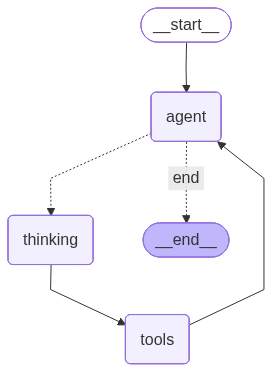

In [ ]:
# Visualize the RAG agent
try:
    from IPython.display import display, Image
    display(Image(rag_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph image: {e}")
    print("\nGraph structure:")
    print(rag_agent.get_graph().draw_ascii())

In [ ]:
# Test the RAG agent
print("Testing Agentic RAG (with local models):")
print("=" * 50)

response = rag_agent.invoke({
    "messages": [HumanMessage(content="What are some tips for better sleep?")]
})

print("\nFinal Response:")
print("=" * 50)
print(response["messages"][-1].content)

Testing Agentic RAG (with local models):

🤔 Planning to execute:
   Tool: search_wellness_knowledge
   Args: {'query': 'sleep tips better sleep'}

Final Response:
Ahoy, sleep‑seeking matey! 🏴‍☠️ Here be some treasure‑trove tips to help ye drift into dreamland smoother than a calm sea:

| ⚓️ Tip | Why it works | How to do it |
|--------|--------------|--------------|
| **Keep a steady bedtime** | A regular schedule trains yer body clock, like a ship’s chronometer. | Go to bed and wake up at the same time every day—even on the galley‑free weekends. |
| **Create a bedtime ritual** | A calm routine signals yer brain that it’s time to drop anchor. | Read a book, stretch lightly, or take a warm bath 30–60 minutes before bed. |
| **Cool, dark, quiet cabin** | Darkness triggers melatonin, the sleep hormone; cool temps keep yer body from overheating. | Aim for 65–68 °F (18–20 °C), use blackout curtains or a sleep mask, and consider white‑noise or earplugs. |
| **Limit screens** | Blue light fro

In [ ]:
# Test with a complex query requiring both RAG and calculation
print("Testing with complex query:")
print("=" * 50)

response = rag_agent.invoke({
    "messages": [HumanMessage(
        content=" I'm stressed and sleeping poorly. What should I do? Also, if I sleep 6 hours a night for a week, how many total hours is that?"
    )]
})

print("\nFinal Response:")
print("=" * 50)
print(response["messages"][-1].content)

Testing with complex query:

🤔 Planning to execute:
   Tool: search_wellness_knowledge
   Args: {'query': 'stress sleep poor sleep hygiene tips'}

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '6*7'}

Final Response:
Ahoy, matey! I hear ye be feelin’ the weight o’ stress and the night’s rest be as scarce as a treasure chest in a storm. Let’s chart a course to calmer seas and sweeter dreams.

### 1. Tacklin’ Stress & Sleep

| What to Do | Why It Helps | How to Do It |
|------------|--------------|--------------|
| **Keep a steady sleep schedule** | A regular rhythm steadies yer body’s internal clock. | Go to bed and wake up at the same time every day, even on the weekends. |
| **Create a calm bedtime routine** | A ritual signals to yer brain that it’s time to wind down. | Read a book, stretch lightly, or take a warm bath 30–60 minutes before bed. |
| **Make yer cabin (bedroom) a sleep haven** | Darkness, coolness, and quiet reduce distractions. | Keep the room 65–68 

In [ ]:
# Test that the agent knows when NOT to use RAG
print("Testing agent decision-making (should NOT use RAG):")
print("=" * 50)

response = rag_agent.invoke({
    "messages": [HumanMessage(content="What is 125 * 8?")]
})

print("\nFinal Response:")
print(response["messages"][-1].content)

Testing agent decision-making (should NOT use RAG):

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '125 * 8'}

Final Response:
Arrr, ye be askin’ a simple math riddle, not a wellness query! The answer be **1,000**. 

But if ye be needin’ any health, fitness, or wellness advice, just holler, and I’ll be ready to set sail on that topic! 

⚠️ *This be no medical advice. Consult a qualified healthcare provider for any health concerns.*


---
## ❓ Question #3:

Compare the experience of building an agent from scratch with LangGraph versus using `create_agent` from Session 3. What are the trade-offs between control and convenience? When would you choose one approach over the other?

##### Answer:
With respect to the tradeoffs between control and convenience comparing create_agent to building an agent from scratch, create_agent offers conveninece and reliability, but with limited control- Out of the box it includes everything needed for general use(iteration limits, middleware support, error handling, checkpointing), but it isn't easily customized. 

Agents built from scratch on the other hand provide much greater control and flexibility, but are more complext to design and implement, and cause potentially more/more difficult bugs owing to the increased complexity. Custom builds allow you to define every node, edge, and routing decision, with custom logic able to be added anywhere along the chain, providing far greater flexibility than create_agent. 

As for situations when one is a better fit, create_agent is the right choice for simplicity, speed of implementation, and robustness/maintainability. It's s great choice when prototyping or setting up an mvp where speed is essential. It's also a great choice for any situation where standarized agent functions are the rule and no customization is needed or wanted. From scratch makes the most sense when custom routing or other logic is needed, or when much greater granular control is needed (custom logging or production debugging, in-depth monitoring). Ideal for situations requiring complex or highly customized implementations. 

## ❓ Question #4:

We used local models (gpt-oss:20b and embeddinggemma) instead of cloud APIs. What are the advantages and disadvantages of this approach? 

##### Answer:
Local Open-Source Models vs Cloud APIs:

Local models offer greater privacy and security at a relatively lower cost. They allow for end-to-end customization and don't require internet (except for api hooks for tool calls or similar). But they have lower-quality performance and less reasoning capability (because they're smaller), and they suck up a lot of GPU/RAM. They're also more complex to setup and maintain, and they come "out of the box" with pretty much nothing. 

State-of-the-art Cloud API models offer superior reasoning and accuracy, and are optimized for scalable high-volume production. They're updated and maintained automatically with nothing required from the user, and they can include a large number of advanced features such as Built-in tools (web search, vision, code execution, file analysis), and multimodal processing capabilities (can process text, images, audio, video). They're super easy to set up and maintain and they aren't overly compute-expensive... but the tradeoff is privacy and security first & foremost. Also, costs can skyrocket at scale for high volumes, and customization and control are limited. 



---
## 🏗️ Activity #2: Extend the Agent with Memory

LangGraph supports **checkpointing** which enables conversation memory across invocations.

Your task: Add memory to the RAG agent so it can:
1. Remember previous questions in the conversation
2. Reference past context when answering new questions
3. Build on previous answers

Hint: Use `MemorySaver` from `langgraph.checkpoint.memory` and pass a `thread_id` in the config.

**📚 Documentation:**
- [LangGraph Persistence & Memory](https://langchain-ai.github.io/langgraph/concepts/persistence/)
- [How to add memory to your graph](https://langchain-ai.github.io/langgraph/how-tos/persistence/)
- [MemorySaver Reference](https://langchain-ai.github.io/langgraph/reference/checkpoints/#langgraph.checkpoint.memory.MemorySaver)

In [28]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
print("Checkpointer created!")


Checkpointer created!


In [30]:
# Agent graphrecompiled with checkpointer 
rag_workflow = StateGraph(AgentState)

# Add nodes
rag_workflow.add_node("agent", rag_agent_node)
rag_workflow.add_node("tools", rag_tool_node)
rag_workflow.add_node("thinking", thinking_node) 

# Set entry point
rag_workflow.add_edge(START, "agent")
# Add conditional edge
rag_workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"thinking": "thinking", "end": END}
)
# Add edge from thinking to tools
rag_workflow.add_edge("thinking", "tools")
# Add edge from tools back to agent
rag_workflow.add_edge("tools", "agent")


# Compile with checkpointer
rag_agent = rag_workflow.compile(checkpointer=checkpointer)

print("Agent compiled with checkpointer")


Agent compiled with checkpointer


In [ ]:
# Test the memory-enabled agent with a multi-turn conversation

from langchain_core.messages import HumanMessage

thread_id = "conversation-Testee P McTesterson"
config = {"configurable": {"thread_id": thread_id}}

print("="*60)
print("CONVERSATION WITH MEMORY")
print("="*60)

def chat(user_message):
    """Send a message and get response"""
    # Get current state
    current_state = rag_agent.get_state(config)
    
    # Build messages list
    if current_state.values:
        # Add to existing conversation
        messages = current_state.values["messages"] + [HumanMessage(content=user_message)]
    else:
        # Start new conversation
        messages = [HumanMessage(content=user_message)]
    
    # Invoke agent
    result = rag_agent.invoke({"messages": messages}, config=config)
    
    return result['messages'][-1].content

# Test conversation
print("\n👤 Turn 1: What's 10 + 5?")
response1 = chat("What's 10 + 5?")
print(f"🤖 Agent: {response1}\n")

print("👤 Turn 2: What was that number again?")
response2 = chat("What was that number again?")
print(f"🤖 Agent: {response2}\n")

print("👤 Turn 3: Now multiply it by 3")
response3 = chat("Now multiply it by 3")
print(f"🤖 Agent: {response3}\n")

print("="*60)

CONVERSATION WITH MEMORY

👤 Turn 1: What's 10 + 5?

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '10 + 5'}
🤖 Agent: Arrr, the sum of 10 and 5 be 15, matey!

👤 Turn 2: What was that number again?
🤖 Agent: Ahoy! The number be 15, me hearty!

👤 Turn 3: Now multiply it by 3

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '15 * 3'}
🤖 Agent: Aye, 15 times 3 be 45, ye scallywag!



In [ ]:
from langchain_core.messages import HumanMessage

print("="*60)
print("AGENT END-TO-END TEST")
print("="*60)

def chat(msg, thread):
    """Send message and get response"""
    config = {"configurable": {"thread_id": thread}}
    state = rag_agent.get_state(config)
    messages = (state.values["messages"] if state.values else []) + [HumanMessage(content=msg)]
    return rag_agent.invoke({"messages": messages}, config=config)['messages'][-1].content

# Test 1: Memory across turns
print("\n[MEMORY TEST - Thread 1]")
print("👤 What's 12 * 8?")
print(f"🤖 {chat('What is 12 * 8?', 'thread1')}\n")
print("👤 Add 20 to that")
print(f"🤖 {chat('Add 20 to that', 'thread1')}\n")

# Test 2: Multi-tool + Thread isolation
print("[MULTI-TOOL + ISOLATION - Thread 2]")
print("👤 What's 50 / 5 and what's the current time?")
print(f"🤖 {chat('What is 50 divided by 5, and what is the current time?', 'thread2')}\n")

# Test 3: RAG retrieval
print("[RAG RETRIEVAL - Thread 3]")
print("👤 What's in your knowledge base?")
print(f"🤖 {chat('What information is in your knowledge base?', 'thread3')}\n")

# Test 4: Thread isolation check
print("[THREAD ISOLATION CHECK - Back to Thread 2]")
print("👤 What was our last calculation?")
print(f"🤖 {chat('What was our last calculation?', 'thread2')}\n")

print("="*60)
print("✅ Tests: Memory, Multi-tool, RAG, Thread Isolation")
print("="*60)

AGENT END-TO-END TEST

[MEMORY TEST - Thread 1]
👤 What's 12 * 8?

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '12 * 8'}
🤖 Arrr, the result of 12 * 8 be 96, ye hearty!

👤 Add 20 to that

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '96 + 20'}
🤖 The sum of 96 and 20 is 116, matey!

[MULTI-TOOL + ISOLATION - Thread 2]
👤 What's 50 / 5 and what's the current time?

🤔 Planning to execute:
   Tool: calculate
   Args: {'expression': '50 / 5'}

🤔 Planning to execute:
   Tool: get_current_time
   Args: {}
🤖 Ahoy, matey! Here’s the quick fix:

- **50 ÷ 5** = **10** (or 10.0 if ye prefer the decimal).
- **Current time**: **2026‑01‑26 18:01:11**.

If ye need anything else, just give a shout! Arr!

[RAG RETRIEVAL - Thread 3]
👤 What's in your knowledge base?
🤖 Ahoy, ye scallywag! 🎩⚓️

The booty I’ve got on this here ship is a chest full o’ wellness wisdom, ready to keep yer body, mind, and spirit in tip‑top shape:

| **Domain** | **What ye’ll find** |
|-----

---
## Summary

In this session, we:

1. **Built agents from scratch** using LangGraph's low-level primitives (StateGraph, nodes, edges)
2. **Used local open-source models** with Ollama (gpt-oss:20b + embeddinggemma)
3. **Transitioned to LangChain** for document loading and text splitting
4. **Created an Agentic RAG system** that intelligently decides when to retrieve information

### Key Takeaways:

- **StateGraph** gives you full control over agent architecture
- **Conditional edges** enable dynamic routing based on LLM decisions
- **Local models** provide privacy and cost savings, with trade-offs in performance
- **LangSmith** provides crucial visibility regardless of where your models run

### What's Next?

Now that you understand the fundamentals, you can:
- Add more sophisticated routing logic
- Implement human-in-the-loop patterns
- Build multi-agent systems
- Deploy to production with LangGraph Platform

**📚 Further Reading:**
- [LangGraph How-To Guides](https://langchain-ai.github.io/langgraph/how-tos/)
- [Human-in-the-Loop Patterns](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/)
- [Multi-Agent Architectures](https://langchain-ai.github.io/langgraph/concepts/multi_agent/)
- [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/)